In [1]:
import torch
import numpy as np
import pandas as pd

emb = torch.load(
    "embeddings_common_only/fold_4_embeddings.pt"
)

tissue_emb = emb["epoch99"]["tissue"]
plasma_emb = emb["epoch99"]["plasma"]


patients = sorted(
    set(tissue_emb.keys()) &
    set(plasma_emb.keys())
)

print(len(patients))

10


In [2]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
def plot(pca_df, fold, proj = False, epoch=0):
    patients = sorted(
    set(pca_df["patient"])
    )

    # Create a color mapping for patients
    colors = cm.get_cmap("tab20", len(patients))
    patient_colors = {
        patient: colors(i)
        for i, patient in enumerate(patients)
    }

    plt.figure(figsize=(7,6))



    for patient in patients:

        color = patient_colors[patient]

        tissue = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Tissue")
        ].iloc[0]

        plasma = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Plasma")
        ].iloc[0]

        t = tissue[["PC1", "PC2"]].values
        p = plasma[["PC1", "PC2"]].values


        plt.scatter(
            t[0],
            t[1],
            marker="o",
            color = color,
            label="Tissue" if patient == patients[0] else ""
        )

        plt.scatter(
            p[0],
            p[1],
            marker="^",
            color=color,
            label="Plasma" if patient == patients[0] else ""

        )


        plt.plot(
            [t[0],p[0]],
            [t[1],p[1]],
            color=color,
            alpha=0.3
        )

    if proj == True:
        emb_type = 'projected embedding'
    else:
        emb_type = 'encoded embedding'
    plt.title(
        f"Patient-wise tissue-plasma {emb_type} alignment after {epoch} epochs"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()


    # plt.savefig(f'embeddings/plots/embeddings_fold_{fold}_{epoch}_{emb_type}.png',
    #     bbox_inches="tight")
    plt.show()




In [3]:
def compute_PCA(plasma_emb, tissue_emb):
    X = []
    labels = []
    modalities = []
    patients = sorted(
        set(tissue_emb.keys()) &
        set(plasma_emb.keys())
    )

    for patient in patients:

        X.append(
            tissue_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Tissue")


        X.append(
            plasma_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Plasma")


    X = np.stack(X)
    pca = PCA(
        n_components=2
    )

    X_pca = pca.fit_transform(X)
    pca_df = pd.DataFrame({
    "patient": labels,
    "modality": modalities,
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1]
})
    return pca, pca_df


In [4]:
def paired_distances_per_pc(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        distances = []

        for patient in pca_df["patient"].unique():

            tissue = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Tissue")
            ][pc].values[0]

            plasma = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Plasma")
            ][pc].values[0]

            distances.append(abs(tissue - plasma))

        results.append({
            "PC": pc,
            "mean_distance": np.mean(distances),
            "std_distance": np.std(distances)
        })

    return pd.DataFrame(results)

In [5]:
def modality_separation(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        tissue_values = pca_df[
            pca_df["modality"] == "Tissue"
        ][pc]

        plasma_values = pca_df[
            pca_df["modality"] == "Plasma"
        ][pc]

        separation = abs(
            tissue_values.mean() -
            plasma_values.mean()
        )

        results.append({
            "PC": pc,
            "modality_separation": separation,
            "tissue_mean": tissue_values.mean(),
            "plasma_mean": plasma_values.mean()
        })

    return pd.DataFrame(results)

In [6]:
def visualize_embeddings(proj=False):
    all_pc_distances = []
    all_pc_separations = []
    all_variance =[]

    for fold in range(5):
        if proj:
            emb = torch.load(
            f"embeddings_common_only/fold_{fold}_embeddings_proj.pt"
            )
        else:
            emb = torch.load(
            f"embeddings_common_only/fold_{fold}_embeddings.pt"
            )

        tissue_emb_0 = emb["epoch0"]["tissue"]
        plasma_emb_0 = emb["epoch0"]["plasma"]

        tissue_emb_99 = emb["epoch99"]["tissue"]
        plasma_emb_99 = emb["epoch99"]["plasma"]

        pca_0, pca_0_df = compute_PCA(plasma_emb_0, tissue_emb_0)
        pca_99, pca_99_df = compute_PCA(plasma_emb_99, tissue_emb_99)

        pc_99_values = pca_99_df[["PC1", "PC2"]].values
        from sklearn.metrics import roc_auc_score

        for pc in ["PC1", "PC2"]:

            values = pca_99_df[pc].values

            labels = (
                pca_99_df["modality"] == "Plasma"
            ).astype(int)

            auc = roc_auc_score(labels, values)

            print(pc, auc)


        distance = paired_distances_per_pc(pca_99_df)
        distance["fold"] = fold
        print(f'Distances Fold {fold}')
        print(distance)

        all_pc_distances.append(distance)

        separation = modality_separation(pca_99_df)
        separation["fold"] = fold

        print(f"Fold {fold} separation")
        print(separation)
        all_pc_separations.append(separation)

        explained_variance = pd.DataFrame({
        "PC": [f"PC{i+1}" for i in range(len(pca_99.explained_variance_ratio_))],
        "explained_variance": pca_99.explained_variance_ratio_,
        "fold": fold
        })

        all_variance.append(explained_variance)

        plt.bar(
        range(1,3),
        pca_99.explained_variance_ratio_,
        )
        plt.title(f'explained variance ratio for fold {fold}')
        plt.xlabel("PC")
        plt.ylabel("Explained variance")
        plt.show()
        plot(pca_0_df, fold=fold, proj=proj,epoch=0)
        plot(pca_99_df,fold=fold, proj=proj,epoch=99)

    all_pc_distances = pd.concat(
    all_pc_distances,
    ignore_index=True
)
    all_pc_separations = pd.concat(all_pc_separations,ignore_index=True)
    all_variance = pd.concat(all_variance,ignore_index=True)


    return all_pc_distances, all_pc_separations, all_variance




PC1 0.4297520661157025
PC2 0.3305785123966942
Distances Fold 0
    PC  mean_distance  std_distance  fold
0  PC1       0.481692      0.234154     0
1  PC2       0.243088      0.180406     0
Fold 0 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.205382     0.102691    -0.102691     0
1  PC2             0.144284     0.072142    -0.072142     0


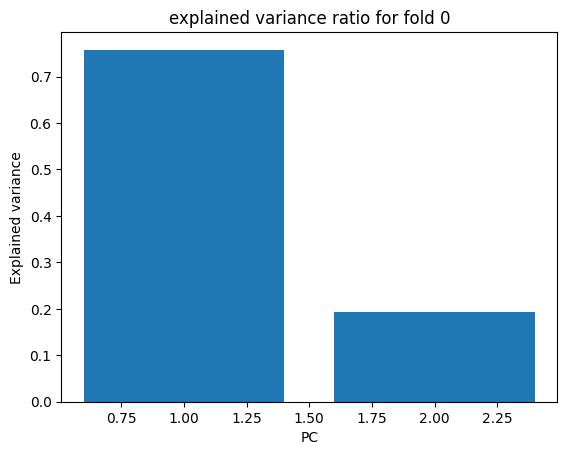

/home/bmep/plalfken/tmp/ipykernel_2390288/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


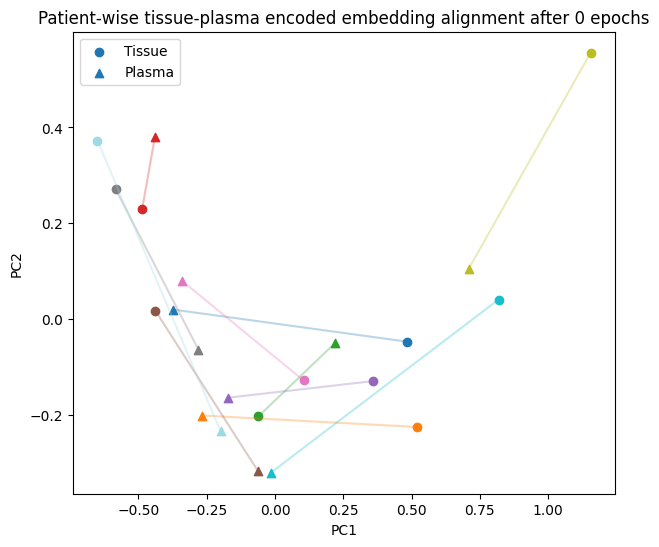

/home/bmep/plalfken/tmp/ipykernel_2390288/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


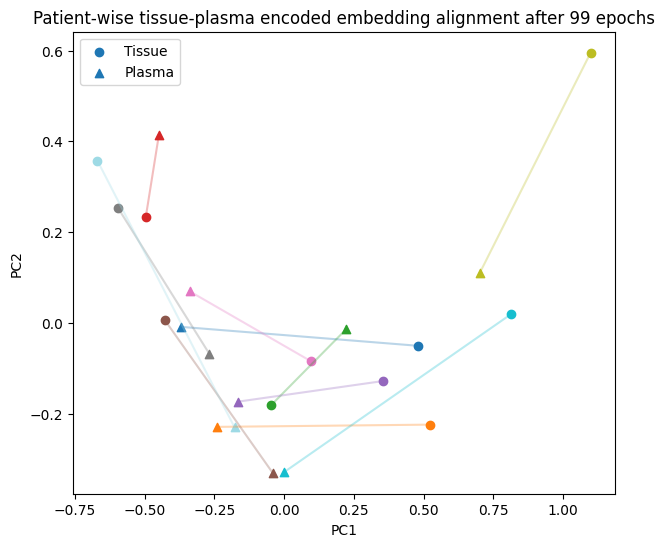

PC1 0.5371900826446281
PC2 0.487603305785124
Distances Fold 1
    PC  mean_distance  std_distance  fold
0  PC1       0.979052      0.789556     1
1  PC2       0.973735      0.778902     1
Fold 1 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.169461    -0.084731     0.084731     1
1  PC2             0.014678     0.007339    -0.007339     1


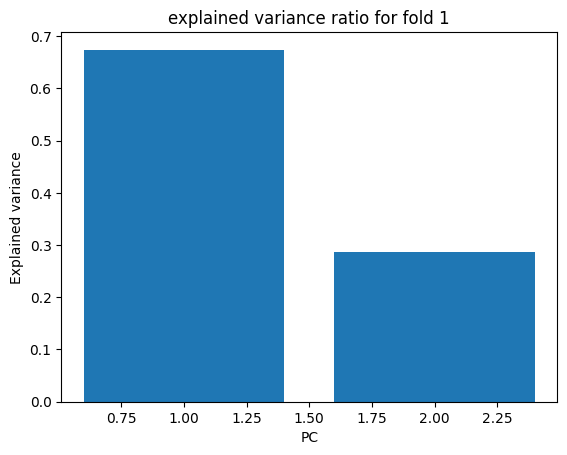

/home/bmep/plalfken/tmp/ipykernel_2390288/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


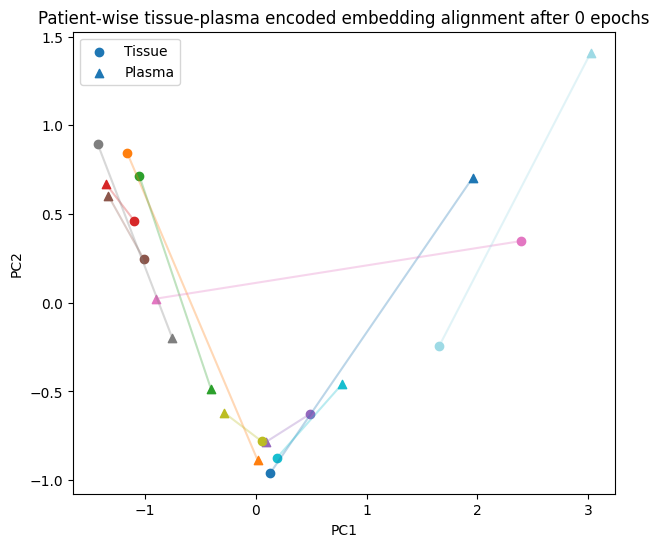

/home/bmep/plalfken/tmp/ipykernel_2390288/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


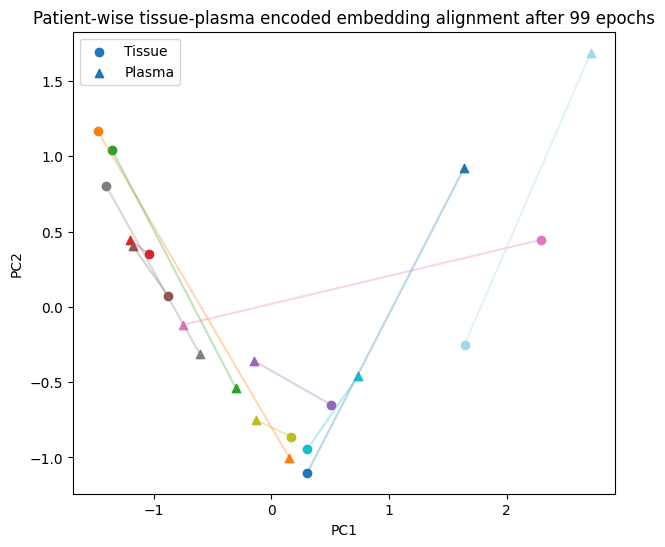

PC1 0.54
PC2 0.67
Distances Fold 2
    PC  mean_distance  std_distance  fold
0  PC1       1.206159      0.541664     2
1  PC2       0.650201      0.498024     2
Fold 2 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.236429    -0.118214     0.118214     2
1  PC2             0.345082    -0.172541     0.172541     2


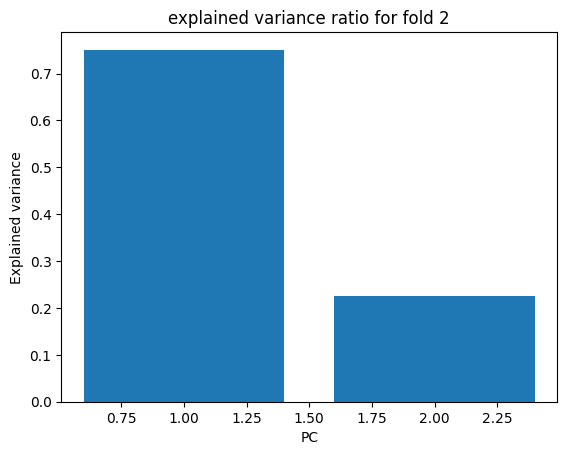

/home/bmep/plalfken/tmp/ipykernel_2390288/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


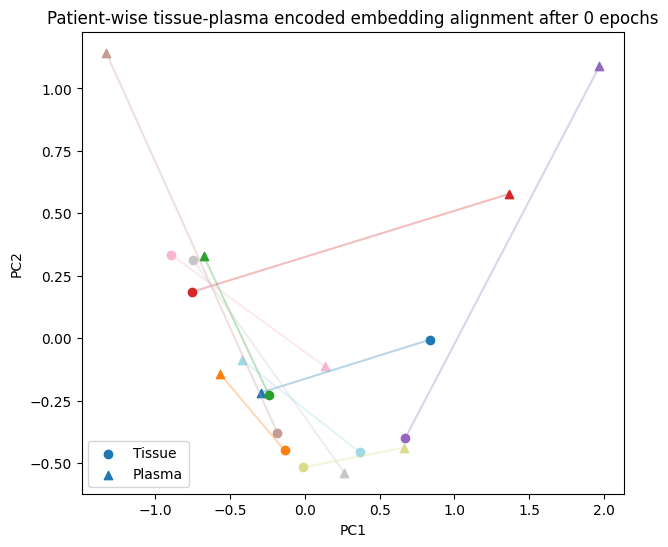

/home/bmep/plalfken/tmp/ipykernel_2390288/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


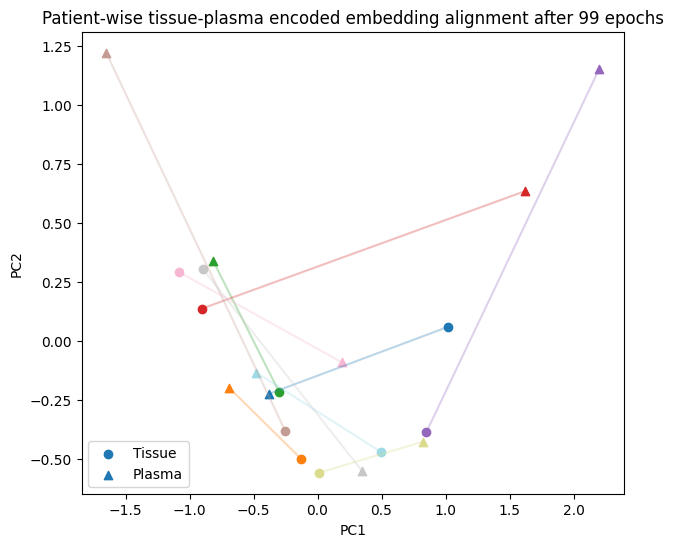

PC1 0.42
PC2 0.21
Distances Fold 3
    PC  mean_distance  std_distance  fold
0  PC1       1.066168      0.857408     3
1  PC2       0.437682      0.187384     3
Fold 3 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.301252     0.150626    -0.150626     3
1  PC2             0.285190     0.142595    -0.142595     3


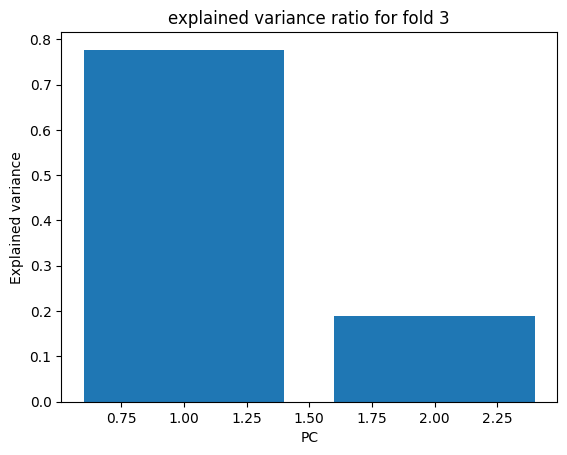

/home/bmep/plalfken/tmp/ipykernel_2390288/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


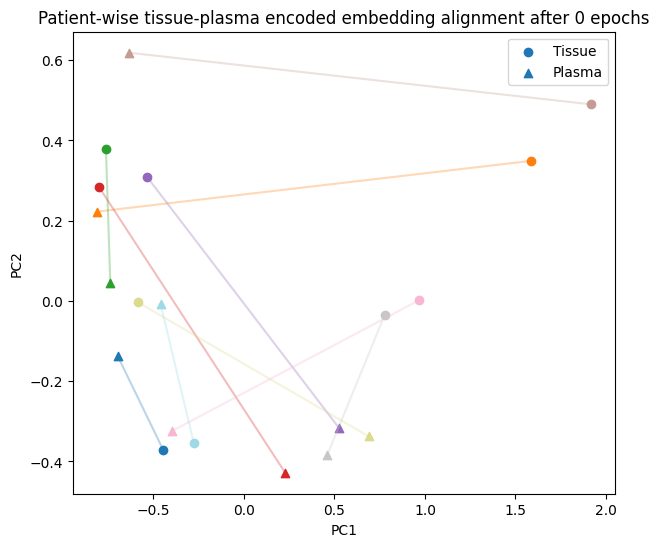

/home/bmep/plalfken/tmp/ipykernel_2390288/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


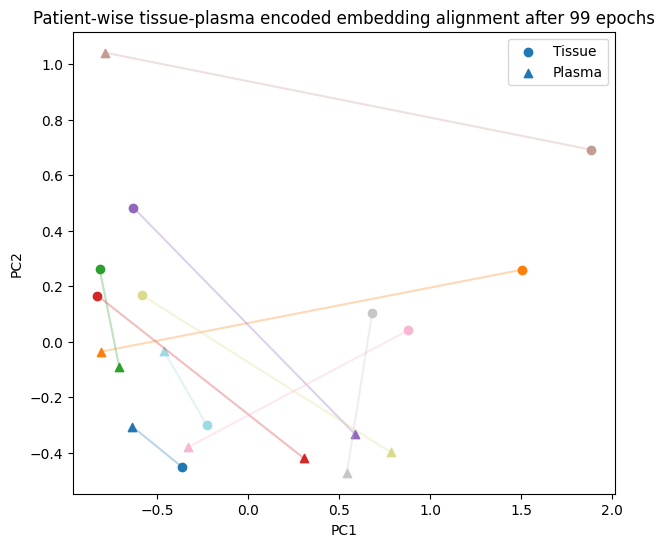

PC1 0.6
PC2 0.36
Distances Fold 4
    PC  mean_distance  std_distance  fold
0  PC1       0.866951      0.864921     4
1  PC2       0.452236      0.435659     4
Fold 4 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             0.023117    -0.011559     0.011558     4
1  PC2             0.249054     0.124527    -0.124527     4


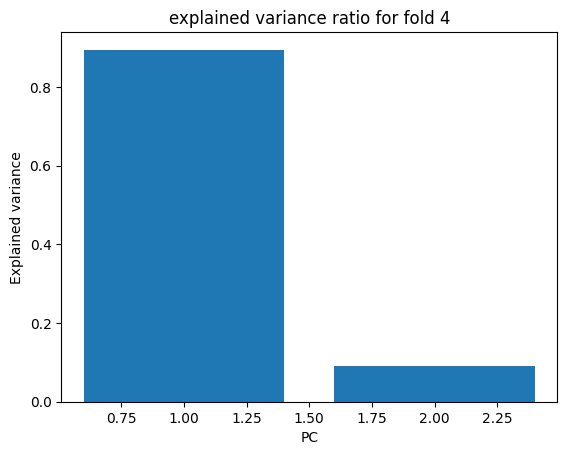

/home/bmep/plalfken/tmp/ipykernel_2390288/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


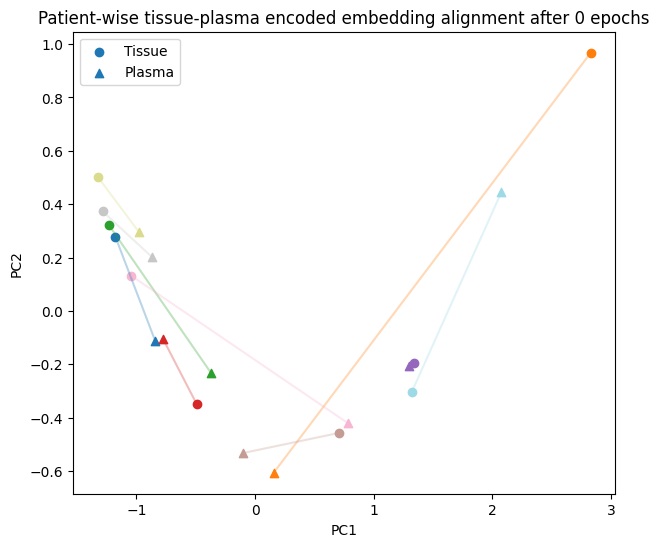

/home/bmep/plalfken/tmp/ipykernel_2390288/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


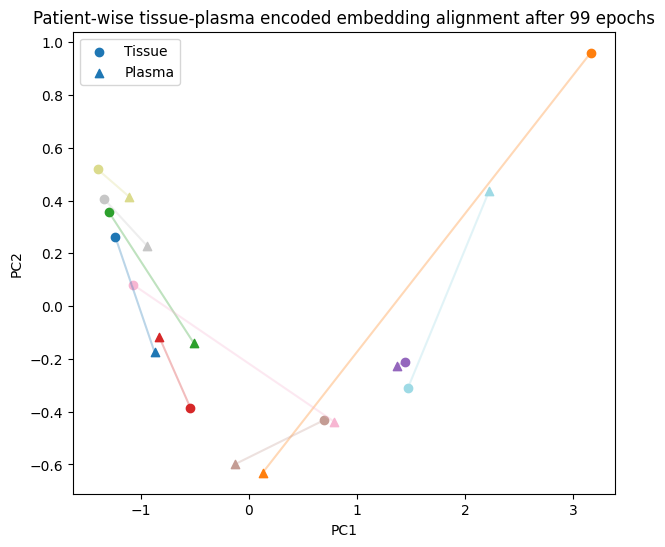

In [7]:
all_distances, all_separations, all_variance = visualize_embeddings(proj=False)

In [48]:
summary_df = (
    all_distances
    .groupby("PC")
    .agg(
        mean_distance_across_folds=("mean_distance", "mean"),
        std_distance_across_folds=("std_distance", "mean")

    )
    .reset_index()
)

print(summary_df)

    PC  mean_distance_across_folds  std_distance_across_folds
0  PC1                    2.224460                   0.122611
1  PC2                    0.599815                   0.181962


In [59]:
summary_df_2 = all_separations.groupby("PC").agg(
        mean_separation_across_folds=("modality_separation", "mean")).reset_index()


print(summary_df_2)

    PC  mean_separation_across_folds
0  PC1                      2.224460
1  PC2                      0.220479


In [44]:
print(all_distances)

[    PC  mean_distance  std_distance  fold
0  PC1       2.054491      0.076721     0
1  PC2       0.573834      0.303596     0,     PC  mean_distance  std_distance  fold
0  PC1       2.222552      0.287422     1
1  PC2       0.298484      0.152715     1,     PC  mean_distance  std_distance  fold
0  PC1       2.171693      0.125998     2
1  PC2       0.652021      0.419667     2,     PC  mean_distance  std_distance  fold
0  PC1       2.376935      0.136578     3
1  PC2       0.723256      0.309087     3,     PC  mean_distance  std_distance  fold
0  PC1       2.296628      0.719429     4
1  PC2       0.751479      0.862283     4]


In [58]:
variance_summary = (
    all_variance
    .groupby("PC")
    .agg(
        mean_variance=("explained_variance", "mean"),
        std_variance=("explained_variance", "std")
    )
    .reset_index()
)

print(variance_summary)

    PC  mean_variance  std_variance
0  PC1       0.563951      0.126033
1  PC2       0.293889      0.060285


In [2]:
X = []
labels = []
modalities = []

for patient in patients:

    X.append(
        tissue_emb[patient].numpy()
    )
    labels.append(patient)
    modalities.append("Tissue")


    X.append(
        plasma_emb[patient].numpy()
    )
    labels.append(patient)
    modalities.append("Plasma")


X = np.stack(X)

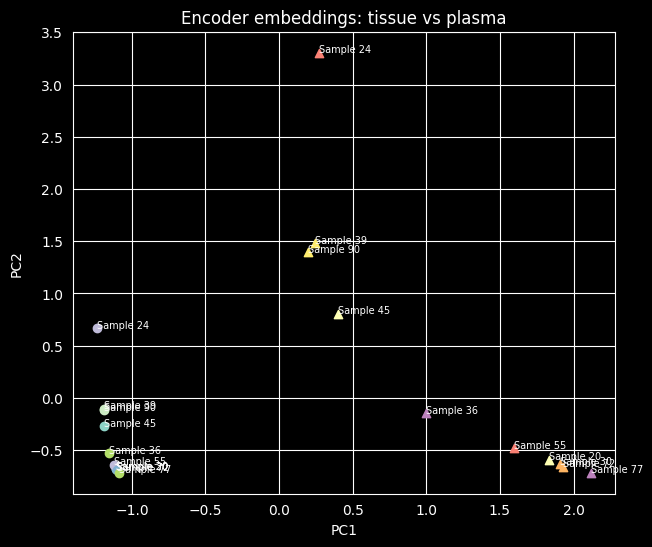

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)


plt.figure(figsize=(7,6))

for i in range(len(X_pca)):

    if modalities[i] == "Tissue":
        marker = "o"
    else:
        marker = "^"

    plt.scatter(
        X_pca[i,0],
        X_pca[i,1],
        marker=marker
    )

    plt.text(
        X_pca[i,0],
        X_pca[i,1],
        labels[i],
        fontsize=7
    )


plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Encoder embeddings: tissue vs plasma")

plt.show()

In [4]:
from sklearn.metrics.pairwise import cosine_distances

distances=[]

for patient in patients:

    d = cosine_distances(
        tissue_emb[patient].numpy().reshape(1,-1),
        plasma_emb[patient].numpy().reshape(1,-1)
    )[0,0]

    distances.append(d)


print(
    "Mean paired cosine distance:",
    np.mean(distances)
)
#
#

Mean paired cosine distance: 0.5806153


In [5]:
random_dist=[]

for i,p1 in enumerate(patients):

    p2 = patients[(i+1)%len(patients)]

    d = cosine_distances(
        tissue_emb[p1].numpy().reshape(1,-1),
        plasma_emb[p2].numpy().reshape(1,-1)
    )[0,0]

    random_dist.append(d)


print(
    "Mean random distance:",
    np.mean(random_dist)
)

Mean random distance: 0.62118995


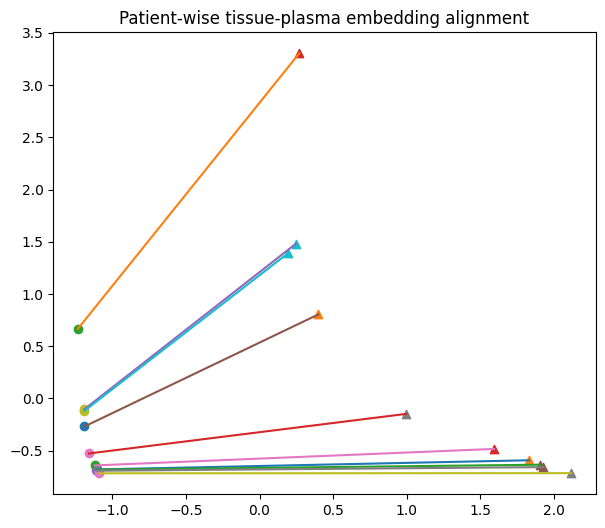

In [8]:
plt.figure(figsize=(7,6))


for patient in patients:

    t = pca.transform(
        tissue_emb[patient].numpy().reshape(1,-1)
    )[0]

    p = pca.transform(
        plasma_emb[patient].numpy().reshape(1,-1)
    )[0]


    plt.scatter(
        t[0],
        t[1],
        marker="o"
    )

    plt.scatter(
        p[0],
        p[1],
        marker="^"
    )


    plt.plot(
        [t[0],p[0]],
        [t[1],p[1]]
    )


plt.title(
    "Patient-wise tissue-plasma embedding alignment"
)

plt.show()